# Phase 7b: Rationale-Driven LLM Selection (Stage A)

Tests condition `per_parent_rationale`: the LLM is shown a parent's past highlights
**and their stated reasons**, then asked to adopt that parent's reasoning perspective
before scoring a new scenario.

Shares the same cache file as `6_llm_selection.ipynb`; Cell 10 compares
`per_parent_rationale` against `per_parent` and `zero_shot` from that notebook.

In [1]:
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install', '-q',
    'anthropic', 'python-dotenv', 'scikit-learn'], check=False)
print('Dependencies ready.')

Dependencies ready.


In [2]:
import os, json, pickle, glob, time, re, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

from dotenv import load_dotenv
import anthropic

_nb_dir = os.path.abspath('.')
load_dotenv(os.path.join(_nb_dir, '..', '..', '.env'))
client = anthropic.Anthropic(api_key=os.environ['CLAUDE_API_KEY'])
MODEL = 'claude-sonnet-4-6'
SEED = 20260506
np.random.seed(SEED)

TRACES_DIR = os.path.join(_nb_dir, '..', 'traces')
CACHE_PATH = os.path.join(TRACES_DIR, 'llm_selection_cache.json')  # shared with nb 6

with open(os.path.join(TRACES_DIR, 'panel_meta.pkl'), 'rb') as f:
    panel_meta = pickle.load(f)
with open(os.path.join(TRACES_DIR, 'span_universe_df.pkl'), 'rb') as f:
    span_universe_df = pickle.load(f)
with open(os.path.join(TRACES_DIR, 'df_sel_dedup.pkl'), 'rb') as f:
    df_sel_dedup = pickle.load(f)

_exports = sorted(glob.glob(os.path.join(
    _nb_dir, '..', '..', '..', 'data-exports', '*', 'moderation_sessions_export_*.csv')))
DATA_DIR = os.path.dirname(_exports[-1])
EXPORT_TS = os.path.basename(_exports[-1]).split('_export_')[1].replace('.csv', '')

mod_df = pd.read_csv(os.path.join(DATA_DIR, f'moderation_sessions_export_{EXPORT_TS}.csv'))
mod_df['is_final_version'] = mod_df['is_final_version'].astype(str).str.strip().str.lower()
mod_df = mod_df[mod_df['is_final_version'].isin(['true', '1'])].copy()
mod_df = mod_df[mod_df['user_id'].isin(set(df_sel_dedup['parent_id']))].copy()

print(f'panel_meta:       {panel_meta.shape}  positive rate: {panel_meta["y"].mean():.1%}')
print(f'span_universe_df: {span_universe_df.shape}')
print(f'df_sel_dedup:     {df_sel_dedup.shape}')
print(f'mod_df (final):   {mod_df.shape}')

panel_meta:       (1612, 31)  positive rate: 10.4%
span_universe_df: (836, 9)
df_sel_dedup:     (200, 48)
mod_df (final):   (83, 38)


## 7b.1  Build scenario text lookup

In [3]:
scenario_text = {}
for sid in span_universe_df['scenario_id'].unique():
    spans = (span_universe_df[span_universe_df['scenario_id'] == sid]
             .sort_values('sent_idx'))
    mod_rows = mod_df[mod_df['scenario_id'] == sid]
    if mod_rows.empty:
        continue
    mod_row = mod_rows.iloc[0]
    scenario_text[sid] = {
        'prompt':    mod_row['scenario_prompt'],
        'sentences': list(zip(spans['sent_idx'].tolist(), spans['text'].tolist())),
    }

print(f'Scenarios with text: {len(scenario_text)}')

Scenarios with text: 45


## 7b.2  Build example banks

In [4]:
N_GLOBAL = 6

parent_examples = {}
for pid, grp in df_sel_dedup.groupby('parent_id'):
    entries = []
    for _, row in grp.sort_values('scenario_id').iterrows():
        sid = row['scenario_id']
        if sid not in scenario_text:
            continue
        entries.append({
            'scenario_id':    sid,
            'highlight_text': str(row['highlight_text']),
            'rationale_text': str(row.get('rationale_text', '')) if pd.notna(row.get('rationale_text')) else '',
            'scenario_prompt': str(scenario_text[sid]['prompt']),
        })
    parent_examples[pid] = entries

global_examples = [
    {**ex, 'parent_id': pid}
    for pid, exs in parent_examples.items()
    for ex in exs
]

print(f'Global pool: {len(global_examples)} examples')
for pid, exs in sorted(parent_examples.items()):
    n_scen = len(set(e['scenario_id'] for e in exs))
    print(f'  Parent {pid}: {len(exs):3d} highlights across {n_scen} scenarios')

Global pool: 200 examples
  Parent 01842943-df97-48af-b7c2-577ca2d3dff7:  12 highlights across 4 scenarios
  Parent 08067f0e-43a9-4578-9302-aec81b38dfb3:  14 highlights across 4 scenarios
  Parent 0cc5f7a1-0d10-4058-b143-89359442904b:  19 highlights across 4 scenarios
  Parent 1bda9733-3ffb-41fa-ba7b-228820abe61c:   4 highlights across 3 scenarios
  Parent 3668ceba-1856-42d1-baed-5d35f9dfd4f0:   7 highlights across 4 scenarios
  Parent 53b10974-dcb5-4ed8-886e-d2fa2719802e:   7 highlights across 4 scenarios
  Parent 620f9606-c49d-4fa2-8c58-132d5f0d8477:   5 highlights across 4 scenarios
  Parent 6254e891-6c80-4d57-b62c-ab7be3460d0b:   5 highlights across 4 scenarios
  Parent 9945a7e3-1a9b-4940-89cf-3e2571a0dcf5:   4 highlights across 4 scenarios
  Parent aae34961-d3ea-4772-a027-5ebf40ababf1:   4 highlights across 2 scenarios
  Parent bb385a79-a474-40cb-abd9-59c7bd5fdc39:   6 highlights across 4 scenarios
  Parent bd2d81fb-d3d8-40b1-a6f7-93818b8c4867:  12 highlights across 4 scenarios
  

## 7b.3  Rationale-driven prompt builders

**Key difference from nb 6**: the system prompt asks the model to adopt the parent's
perspective by studying their past *reasons*, not just the sentences they flagged.
The examples block leads with the rationale (WHY) before the highlighted sentence.

In [5]:
SYSTEM_BASE = """You are helping review AI responses to children's questions from the perspective of a specific parent.

You will be given examples of how this parent has responded to previous AI responses —
specifically, sentences they found noteworthy and, importantly, *why* those sentences
caught their attention.

Study their reasoning pattern. Then read the new AI response and, thinking as this
parent would, identify which sentences they would most likely pause on or find noteworthy.

Be highly selective. Most sentences will not stand out. It is completely valid to select
none if nothing would genuinely catch this parent's attention.

Respond ONLY with valid JSON listing the 0-based indices of sentences that stand out:
{\"selected\": [2, 5]}
If no sentences stand out: {\"selected\": []}"""


def format_examples_block(examples):
    if not examples:
        return ''
    lines = ["\n=== This parent's past concerns ==="]
    for i, ex in enumerate(examples, 1):
        prompt_short = str(ex['scenario_prompt'])[:120].strip()
        lines.append(f'\nExample {i}:')
        lines.append(f'  Child asked: "{prompt_short}"')
        if ex.get('rationale_text'):
            lines.append(f'  Why it caught their attention: "{ex["rationale_text"]}"')
        lines.append(f'  Sentence they flagged: "{ex["highlight_text"]}"')
    return '\n'.join(lines)


def build_system_prompt(examples):
    ex_block = format_examples_block(examples)
    if ex_block:
        return SYSTEM_BASE + '\n' + ex_block
    return SYSTEM_BASE


def format_user_msg(parent_row, scenario_id, sentences):
    age     = parent_row.get('parent_age_group', 'unknown')
    edu     = parent_row.get('parent_education', 'unknown')
    style   = parent_row.get('parenting_style', 'unknown')
    freq    = parent_row.get('genai_usage_frequency', 'unknown')
    monitor = parent_row.get('parent_llm_monitoring_level', 'unknown')
    age_band   = parent_row.get('age_band', 'unknown')
    gender     = parent_row.get('gender_identity', 'unknown')
    trait      = parent_row.get('trait', 'unknown')
    domain     = parent_row.get('domain', 'unknown')
    sens       = parent_row.get('sensitivity_level', 'unknown')
    space      = parent_row.get('space_type', 'unknown')
    prompt_txt = scenario_text[scenario_id]['prompt']

    lines = [
        'Parent profile:',
        f'  Age: {age}, Education: {edu}, Parenting style: {style}',
        f'  GenAI frequency: {freq}, Monitors child AI use: {monitor}',
        '',
        'Scenario:',
        f'  Child ({age_band}, {gender}, {trait} personality) asked: "{str(prompt_txt)[:200]}"',
        f'  Domain: {domain} | Sensitivity: {sens} | Space: {space}',
        '',
        'AI response sentences:',
    ]
    for idx, text in sentences:
        lines.append(f'{idx}. "{text}"')
    return '\n'.join(lines)


print('Rationale-driven prompt builders defined.')
_pid = panel_meta['parent_id'].iloc[0]
_sid = panel_meta[panel_meta['parent_id'] == _pid]['scenario_id'].iloc[0]
_row = panel_meta[(panel_meta['parent_id'] == _pid) & (panel_meta['scenario_id'] == _sid)].iloc[0]
_ex  = [e for e in parent_examples.get(_pid, []) if e['scenario_id'] != _sid]
print('\n--- Sample system prompt (truncated) ---')
print(build_system_prompt(_ex)[:800])

Rationale-driven prompt builders defined.

--- Sample system prompt (truncated) ---
You are helping review AI responses to children's questions from the perspective of a specific parent.

You will be given examples of how this parent has responded to previous AI responses —
specifically, sentences they found noteworthy and, importantly, *why* those sentences
caught their attention.

Study their reasoning pattern. Then read the new AI response and, thinking as this
parent would, identify which sentences they would most likely pause on or find noteworthy.

Be highly selective. Most sentences will not stand out. It is completely valid to select
none if nothing would genuinely catch this parent's attention.

Respond ONLY with valid JSON listing the 0-based indices of sentences that stand out:
{"selected": [2, 5]}
If no sentences stand out: {"selected": []}

=== This parent's 


## 7b.4  LLM infrastructure

In [6]:
import hashlib

def parse_response(content_blocks, n_sentences):
    text_block = next((b for b in content_blocks if b.type == 'text'), None)
    if text_block is None:
        return [0] * n_sentences
    raw = text_block.text.strip()
    try:
        selected = json.loads(raw)['selected']
    except Exception:
        selected = [int(x) for x in re.findall(r'\d+', raw)]
    binary = [0] * n_sentences
    for idx in selected:
        if 0 <= idx < n_sentences:
            binary[idx] = 1
    return binary


def make_batch_id(cache_key):
    return hashlib.md5(cache_key.encode()).hexdigest()[:16]


def call_llm_single(system_prompt, user_msg, n_sentences):
    msg = client.messages.create(
        model=MODEL,
        max_tokens=5000,
        thinking={'type': 'enabled', 'budget_tokens': 4000},
        system=system_prompt,
        messages=[{'role': 'user', 'content': user_msg}],
    )
    return parse_response(msg.content, n_sentences)


def submit_batch(requests):
    batch_requests = [
        {
            'custom_id': r['batch_id'],
            'params': {
                'model': MODEL,
                'max_tokens': 5000,
                'thinking': {'type': 'enabled', 'budget_tokens': 4000},
                'system': r['system'],
                'messages': [{'role': 'user', 'content': r['user_msg']}],
            },
        }
        for r in requests
    ]
    batch = client.messages.batches.create(requests=batch_requests)
    print(f'Batch submitted: {batch.id}  ({len(requests)} requests)')
    return batch.id


def poll_batch(batch_id, poll_interval=30):
    while True:
        batch = client.messages.batches.retrieve(batch_id)
        counts = batch.request_counts
        print(f'  {batch.processing_status}  '
              f'processing={counts.processing}  '
              f'succeeded={counts.succeeded}  '
              f'errored={counts.errored}')
        if batch.processing_status == 'ended':
            break
        time.sleep(poll_interval)
    return {r.custom_id: r for r in client.messages.batches.results(batch_id)}


print('LLM infrastructure defined.')

LLM infrastructure defined.


## 7b.5  Batch infrastructure

In [7]:
CONDITION = 'per_parent_rationale'


def build_requests_for_condition(condition, cache):
    requests = []
    for pid in sorted(panel_meta['parent_id'].unique()):
        pid_scenarios = panel_meta[panel_meta['parent_id'] == pid]['scenario_id'].unique()
        all_parent_ex = parent_examples.get(pid, [])

        for held_sid in sorted(pid_scenarios):
            if held_sid not in scenario_text:
                continue
            cache_key = f"{condition}|{pid}|{held_sid}"
            if cache_key in cache:
                continue
            group = panel_meta[(panel_meta['parent_id'] == pid) &
                               (panel_meta['scenario_id'] == held_sid)]
            sentences = scenario_text[held_sid]['sentences']
            per_parent_ex = [e for e in all_parent_ex if e['scenario_id'] != held_sid]
            requests.append({
                'custom_id':   cache_key,
                'batch_id':    make_batch_id(cache_key),
                'system':      build_system_prompt(per_parent_ex),
                'user_msg':    format_user_msg(group.iloc[0], held_sid, sentences),
                'n_sentences': len(sentences),
            })
    return requests


def run_batch_condition(condition):
    cache = json.load(open(CACHE_PATH)) if os.path.exists(CACHE_PATH) else {}
    requests = build_requests_for_condition(condition, cache)
    print(f'[{condition}] To submit: {len(requests)}  Already cached: {len(cache)}')
    if not requests:
        print('All cached — nothing to submit.')
        return cache
    batch_id_map = {r['batch_id']: (r['custom_id'], r['n_sentences']) for r in requests}
    batch_id = submit_batch(requests)
    batch_results = poll_batch(batch_id, poll_interval=30)
    for bid, result in batch_results.items():
        cache_key, n_sent = batch_id_map[bid]
        if result.result.type == 'succeeded':
            cache[cache_key] = parse_response(result.result.message.content, n_sent)
        else:
            print(f'  ERROR: {cache_key} — {result.result.type}')
    with open(CACHE_PATH, 'w') as f:
        json.dump(cache, f)
    print(f'[{condition}] Done. Cache now has {len(cache)} entries.')
    return cache


def assemble_results(conditions, cache):
    rows = []
    for pid in sorted(panel_meta['parent_id'].unique()):
        for held_sid in sorted(panel_meta[panel_meta['parent_id'] == pid]['scenario_id'].unique()):
            if held_sid not in scenario_text:
                continue
            group = panel_meta[(panel_meta['parent_id'] == pid) &
                               (panel_meta['scenario_id'] == held_sid)]
            for condition in conditions:
                binary = cache.get(f"{condition}|{pid}|{held_sid}", None)
                if binary is None:
                    continue
                for sent_idx, y_pred in enumerate(binary):
                    span_id = f"{held_sid}_sent{sent_idx}"
                    mask = (group['span_id'] == span_id)
                    if mask.any():
                        rows.append({
                            'condition':   condition,
                            'parent_id':   pid,
                            'scenario_id': held_sid,
                            'span_id':     span_id,
                            'y_true':      int(group.loc[mask, 'y'].iloc[0]),
                            'y_pred':      int(y_pred),
                        })
    return pd.DataFrame(rows)


def show_interim_metrics(conditions_done, cache):
    df = assemble_results(conditions_done, cache)
    if df.empty:
        print('No results yet.')
        return df
    actual_rate = panel_meta['y'].mean()
    print(f'Actual highlight rate: {actual_rate:.1%}')
    print(f'{"Condition":20s}  {"F1-macro":>8s}  {"Precision":>9s}  {"Recall":>7s}  {"Sel-rate":>8s}')
    for cond, g in df.groupby('condition'):
        f1m  = f1_score(g['y_true'], g['y_pred'], average='macro', zero_division=0)
        prec = precision_score(g['y_true'], g['y_pred'], zero_division=0)
        rec  = recall_score(g['y_true'], g['y_pred'], zero_division=0)
        rate = g['y_pred'].mean()
        print(f'{cond:20s}  {f1m:8.3f}  {prec:9.3f}  {rec:7.3f}  {rate:8.3f}')
    return df


print('Batch infrastructure defined.')

Batch infrastructure defined.


## 7b.6  Pilot: selection rate calibration

5 synchronous calls to verify the rationale prompt produces a realistic selection rate
before spending the full batch budget. Target: within 0.3×–3× of actual ~10.4%.

In [8]:
PILOT_N = 5
cache = json.load(open(CACHE_PATH)) if os.path.exists(CACHE_PATH) else {}

pairs_with = (panel_meta[panel_meta['y'] == 1][['parent_id', 'scenario_id']]
              .drop_duplicates().sample(3, random_state=SEED))
pairs_without = (panel_meta.groupby(['parent_id', 'scenario_id'])['y']
                 .sum().reset_index()
                 .query('y == 0')[['parent_id', 'scenario_id']]
                 .sample(2, random_state=SEED))
pilot_pairs = pd.concat([pairs_with, pairs_without]).reset_index(drop=True)

pilot_results = []
for _, row in pilot_pairs.iterrows():
    pid, sid = row['parent_id'], row['scenario_id']
    if sid not in scenario_text:
        continue
    group = panel_meta[(panel_meta['parent_id'] == pid) &
                       (panel_meta['scenario_id'] == sid)]
    sentences = scenario_text[sid]['sentences']
    per_parent_ex = [e for e in parent_examples.get(pid, []) if e['scenario_id'] != sid]
    sys_prompt = build_system_prompt(per_parent_ex)
    user_msg   = format_user_msg(group.iloc[0], sid, sentences)
    cache_key  = f"{CONDITION}|{pid}|{sid}"

    if cache_key in cache:
        binary = cache[cache_key]
        print(f'  {cache_key[:60]}: cached')
    else:
        print(f'  Calling LLM for {cache_key[:60]}...')
        binary = call_llm_single(sys_prompt, user_msg, len(sentences))
        cache[cache_key] = binary
        with open(CACHE_PATH, 'w') as f:
            json.dump(cache, f)

    for sent_idx, y_pred in enumerate(binary):
        span_id = f"{sid}_sent{sent_idx}"
        mask = (group['span_id'] == span_id)
        y_true = int(group.loc[mask, 'y'].iloc[0]) if mask.any() else None
        pilot_results.append({'parent_id': pid, 'scenario_id': sid,
                              'sent_idx': sent_idx, 'y_pred': y_pred, 'y_true': y_true})

pilot_df = pd.DataFrame(pilot_results)
pilot_rate  = pilot_df['y_pred'].mean()
actual_rate = panel_meta['y'].mean()

print(f'\nPilot selection rate:  {pilot_rate:.1%}')
print(f'Actual highlight rate: {actual_rate:.1%}')
print(f'Ratio (pilot/actual):  {pilot_rate / actual_rate:.2f}x')

if pilot_rate > 3 * actual_rate:
    print('WARNING: over-selects — tighten system prompt before proceeding.')
elif pilot_rate < 0.3 * actual_rate:
    print('WARNING: under-selects — loosen system prompt before proceeding.')
else:
    print('Selection rate looks reasonable. Proceed to batch cell.')

display(
    pilot_df.groupby(['parent_id', 'scenario_id'])
    .agg(n_sentences=('y_pred', 'count'),
         n_selected=('y_pred', 'sum'),
         n_actual=('y_true', 'sum'))
    .assign(llm_rate=lambda d: d['n_selected'] / d['n_sentences'],
            actual_rate=lambda d: d['n_actual'] / d['n_sentences'])
    .round(3)
)

  per_parent_rationale|08067f0e-43a9-4578-9302-aec81b38dfb3|sc: cached
  per_parent_rationale|ebb747ec-9a89-4e60-ab07-3ec6e8c00e13|sc: cached
  per_parent_rationale|f59ecfa3-c8eb-45b4-a41e-9e4e33846ab7|sc: cached
  per_parent_rationale|0cc5f7a1-0d10-4058-b143-89359442904b|sc: cached
  per_parent_rationale|aae34961-d3ea-4772-a027-5ebf40ababf1|sc: cached

Pilot selection rate:  12.0%
Actual highlight rate: 10.4%
Ratio (pilot/actual):  1.15x
Selection rate looks reasonable. Proceed to batch cell.


,,n_sentences,n_selected,n_actual,llm_rate,actual_rate
parent_id,scenario_id,,,,,
08067f0e-43a9-4578-9302-aec81b38dfb3,scenario_4a646170-1816-4dc9-9fcd-1e01dda7595d,13,3,3,0.231,0.231
0cc5f7a1-0d10-4058-b143-89359442904b,scenario_fd08d23b-03b5-440c-9be0-134306cf5a56,29,2,0,0.069,0.000
aae34961-d3ea-4772-a027-5ebf40ababf1,scenario_a14ed80b-4028-4c1b-a6b1-04c6c087c77d,23,1,0,0.043,0.000
ebb747ec-9a89-4e60-ab07-3ec6e8c00e13,scenario_90d12d1a-bfc2-47f1-9394-8a5de009cb3f,13,3,8,0.231,0.615
f59ecfa3-c8eb-45b4-a41e-9e4e33846ab7,scenario_9066bf8c-15f6-4c3e-951b-63e29008d892,14,2,2,0.143,0.143


## 7b.7  Full batch — `per_parent_rationale`

In [9]:
cache = run_batch_condition(CONDITION)
_ = show_interim_metrics([CONDITION], cache)

[per_parent_rationale] To submit: 78  Already cached: 254
Batch submitted: msgbatch_011k9486F2y9dAzgcDMhhaRb  (78 requests)
  in_progress  processing=78  succeeded=0  errored=0
  in_progress  processing=78  succeeded=0  errored=0
  in_progress  processing=78  succeeded=0  errored=0
  ended  processing=0  succeeded=78  errored=0
[per_parent_rationale] Done. Cache now has 332 entries.
Actual highlight rate: 10.4%
Condition             F1-macro  Precision   Recall  Sel-rate
per_parent_rationale     0.604      0.312    0.262     0.087


In [13]:
# ── per_parent_rationale accuracy breakdown ────────────────────────────────
pr = assemble_results([CONDITION], cache)
if pr.empty:
    print('No results in cache yet — run the batch above first.')
else:
    pr = pr[pr['condition'] == CONDITION]
    y_true = pr['y_true'].values
    y_pred = pr['y_pred'].values
    actual_rate  = panel_meta['y'].mean()
    baseline_acc = 1 - actual_rate

    acc    = accuracy_score(y_true, y_pred)
    prec   = precision_score(y_true, y_pred, zero_division=0)
    rec    = recall_score(y_true, y_pred, zero_division=0)
    f1_mac = f1_score(y_true, y_pred, average='macro', zero_division=0)
    f1_wt  = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    sel_rate = y_pred.mean()

    print('=== per_parent_rationale results (pooled) ===')
    print(f'{"Metric":<20s}  {"Rationale":>10s}  {"Baseline":>10s}')
    print('-' * 45)
    print(f'{"Accuracy":<20s}  {acc:10.3f}  {baseline_acc:10.3f}')
    print(f'{"Precision":<20s}  {prec:10.3f}  {"0.000":>10s}')
    print(f'{"Recall":<20s}  {rec:10.3f}  {"0.000":>10s}')
    print(f'{"F1-macro":<20s}  {f1_mac:10.3f}  {"~0.46":>10s}')
    print(f'{"F1-weighted":<20s}  {f1_wt:10.3f}  {"~0.83":>10s}')
    print(f'{"Selection rate":<20s}  {sel_rate:10.3f}  {"0.000":>10s}')
    print(f'{"Actual highlight rate":<20s}  {actual_rate:10.3f}')

    per_parent_pr = (
        pr.groupby('parent_id')
        .apply(lambda g: pd.Series({
            'accuracy':    accuracy_score(g['y_true'], g['y_pred']),
            'precision':   precision_score(g['y_true'], g['y_pred'], zero_division=0),
            'recall':      recall_score(g['y_true'], g['y_pred'], zero_division=0),
            'f1_macro':    f1_score(g['y_true'], g['y_pred'], average='macro', zero_division=0),
            'sel_rate':    g['y_pred'].mean(),
            'actual_rate': g['y_true'].mean(),
        }))
        .round(3)
    )
    print('\n=== Per-parent breakdown ===')
    display(per_parent_pr)

=== per_parent_rationale results (pooled) ===
Metric                 Rationale    Baseline
---------------------------------------------
Accuracy                   0.863       0.896
Precision                  0.312       0.000
Recall                     0.262       0.000
F1-macro                   0.604       ~0.46
F1-weighted                0.858       ~0.83
Selection rate             0.087       0.000
Actual highlight rate       0.104

=== Per-parent breakdown ===


,accuracy,precision,recall,f1_macro,sel_rate,actual_rate
parent_id,,,,,,
01842943-df97-48af-b7c2-577ca2d3dff7,0.880,0.200,0.111,0.539,0.050,0.090
08067f0e-43a9-4578-9302-aec81b38dfb3,0.869,0.600,0.600,0.761,0.164,0.164
0cc5f7a1-0d10-4058-b143-89359442904b,0.871,0.158,0.214,0.556,0.090,0.067
1bda9733-3ffb-41fa-ba7b-228820abe61c,0.854,0.250,0.250,0.584,0.098,0.098
3668ceba-1856-42d1-baed-5d35f9dfd4f0,0.905,0.500,0.500,0.724,0.095,0.095
53b10974-dcb5-4ed8-886e-d2fa2719802e,0.923,0.333,0.500,0.679,0.077,0.051
620f9606-c49d-4fa2-8c58-132d5f0d8477,0.914,0.000,0.000,0.478,0.029,0.057
6254e891-6c80-4d57-b62c-ab7be3460d0b,0.917,0.250,0.200,0.589,0.048,0.060
9945a7e3-1a9b-4940-89cf-3e2571a0dcf5,0.900,0.167,0.250,0.573,0.075,0.050


## 7b.8  Cross-notebook comparison

Compares `per_parent_rationale` against `per_parent` and `zero_shot` from notebook 6.
All conditions share the same cache file, so this cell needs no recomputation.

In [11]:
COMPARE_CONDITIONS = ['zero_shot', 'per_parent', 'per_parent_rationale']
cache = json.load(open(CACHE_PATH)) if os.path.exists(CACHE_PATH) else {}

results_df = assemble_results(COMPARE_CONDITIONS, cache)
available = results_df['condition'].unique().tolist() if not results_df.empty else []
print(f'Conditions available in cache: {available}')
print(f'Results shape: {results_df.shape}')

actual_rate = panel_meta['y'].mean()
y_all = panel_meta['y'].values
y_maj = np.zeros_like(y_all)

metric_rows = [{
    'condition':      'majority_baseline',
    'precision':      precision_score(y_all, y_maj, zero_division=0),
    'recall':         recall_score(y_all, y_maj, zero_division=0),
    'f1_macro':       f1_score(y_all, y_maj, average='macro', zero_division=0),
    'f1_weighted':    f1_score(y_all, y_maj, average='weighted', zero_division=0),
    'accuracy':       accuracy_score(y_all, y_maj),
    'selection_rate': 0.0,
}]

for condition in COMPARE_CONDITIONS:
    grp = results_df[results_df['condition'] == condition] if not results_df.empty else pd.DataFrame()
    if grp.empty:
        print(f'  {condition}: not yet in cache — skipping.')
        continue
    metric_rows.append({
        'condition':      condition,
        'precision':      precision_score(grp['y_true'], grp['y_pred'], zero_division=0),
        'recall':         recall_score(grp['y_true'], grp['y_pred'], zero_division=0),
        'f1_macro':       f1_score(grp['y_true'], grp['y_pred'], average='macro', zero_division=0),
        'f1_weighted':    f1_score(grp['y_true'], grp['y_pred'], average='weighted', zero_division=0),
        'accuracy':       accuracy_score(grp['y_true'], grp['y_pred']),
        'selection_rate': grp['y_pred'].mean(),
    })

metrics_df = pd.DataFrame(metric_rows).set_index('condition')
print(f'\nActual highlight rate: {actual_rate:.1%}')
print('\n=== Stage A: condition comparison ===')
display(metrics_df.round(3))

# Delta: rationale vs plain per_parent
if 'per_parent_rationale' in metrics_df.index and 'per_parent' in metrics_df.index:
    delta = metrics_df.loc['per_parent_rationale'] - metrics_df.loc['per_parent']
    print('\nper_parent_rationale − per_parent (positive = rationale helps):')
    display(delta.to_frame('delta').T.round(3))

Conditions available in cache: ['zero_shot', 'per_parent', 'per_parent_rationale']
Results shape: (4836, 6)

Actual highlight rate: 10.4%

=== Stage A: condition comparison ===


,precision,recall,f1_macro,f1_weighted,accuracy,selection_rate
condition,,,,,,
majority_baseline,0.000,0.000,0.473,0.847,0.896,0.000
zero_shot,0.264,0.167,0.565,0.851,0.865,0.066
per_parent,0.322,0.220,0.595,0.859,0.870,0.071
per_parent_rationale,0.312,0.262,0.604,0.858,0.863,0.087



per_parent_rationale − per_parent (positive = rationale helps):


,precision,recall,f1_macro,f1_weighted,accuracy,selection_rate
delta,-0.01,0.042,0.009,-0.002,-0.007,0.016


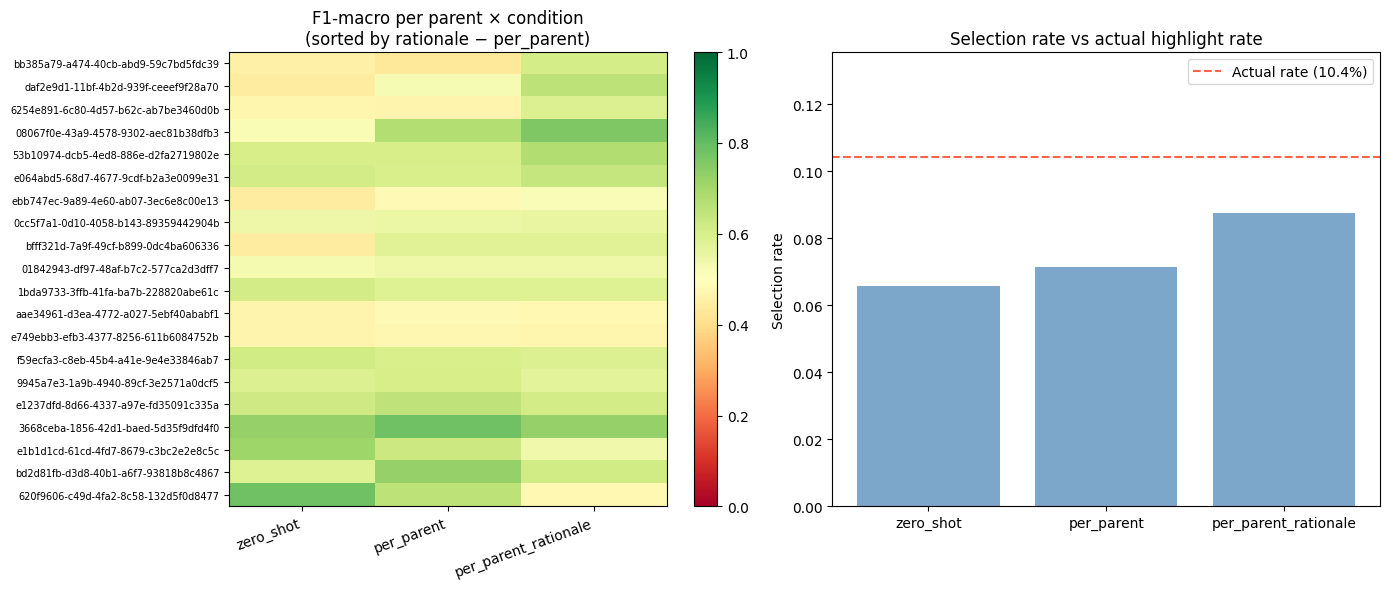

In [12]:
# ── Per-parent F1-macro heatmap ────────────────────────────────────────────
if results_df.empty:
    print('No results to plot yet.')
else:
    parent_f1 = []
    for pid, grp in results_df.groupby('parent_id'):
        for cond, cgrp in grp.groupby('condition'):
            parent_f1.append({
                'parent_id': pid,
                'condition': cond,
                'f1_macro':  f1_score(cgrp['y_true'], cgrp['y_pred'],
                                      average='macro', zero_division=0),
            })

    parent_f1_df = pd.DataFrame(parent_f1)
    plot_conditions = [c for c in COMPARE_CONDITIONS if c in parent_f1_df['condition'].unique()]
    heatmap_data = parent_f1_df.pivot(index='parent_id', columns='condition', values='f1_macro')

    if 'per_parent_rationale' in heatmap_data and 'per_parent' in heatmap_data:
        heatmap_data['_delta'] = heatmap_data['per_parent_rationale'] - heatmap_data['per_parent']
        heatmap_data = heatmap_data.sort_values('_delta', ascending=False).drop(columns='_delta')

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    ax = axes[0]
    im = ax.imshow(heatmap_data[plot_conditions].values, aspect='auto', cmap='RdYlGn', vmin=0, vmax=1)
    ax.set_xticks(range(len(plot_conditions)))
    ax.set_xticklabels(plot_conditions, rotation=20, ha='right')
    ax.set_yticks(range(len(heatmap_data)))
    ax.set_yticklabels(heatmap_data.index, fontsize=7)
    ax.set_title('F1-macro per parent × condition\n(sorted by rationale − per_parent)')
    plt.colorbar(im, ax=ax)

    ax2 = axes[1]
    sel_rates = [metrics_df.loc[c, 'selection_rate'] if c in metrics_df.index else 0
                 for c in plot_conditions]
    ax2.bar(plot_conditions, sel_rates, color='steelblue', alpha=0.7)
    ax2.axhline(actual_rate, color='tomato', linestyle='--', linewidth=1.5,
                label=f'Actual rate ({actual_rate:.1%})')
    ax2.set_ylabel('Selection rate')
    ax2.set_title('Selection rate vs actual highlight rate')
    ax2.legend()
    ax2.set_ylim(0, max(sel_rates + [actual_rate]) * 1.3)

    plt.tight_layout()
    plt.show()